# OmicVerse ?? SPATA2 ??????

?????????? `ov.space` ??? AnnData-native SPATA2 ?????????? draft ?? PR ???? `py-SPATA2` ?????

?????

- API PR: [omicverse/omicverse#847](https://github.com/omicverse/omicverse/pull/847)
- ????: [omicverse/py-SPATA2](https://github.com/omicverse/py-SPATA2)
- SPATA2 ??: [theMILOlab.github.io/SPATA2](https://themilolab.github.io/SPATA2/index.html)


## ???????

???????? SPATA2 ?????????

| SPATA2 ?? | ?????? OmicVerse API | ?? |
|---|---|---|
| ??? | `ov.space.spata2_get_coords` | observation-indexed `DataFrame` |
| ???? / ??? | `ov.space.spata2_join_variables` | ?? + `obs` + ??? |
| ???? | `ov.space.spata2_tissue_outline` | convex outline??? `adata.uns` |
| ???? / ??? | `ov.space.spata2_identify_outliers` | `adata.obs` ?????? |
| ?????? | `ov.space.spata2_remove_outliers` | ???? `AnnData` |
| ???? | `spata2_pixels_to_unit`, `spata2_unit_to_pixels` | ?????? |

?????? SPATA2 ?????? parity ????????? namespace ?????


## ????

? notebook ??? `omicverse`?`AnnData`?`numpy`?`pandas` ? `matplotlib`???? R?`rpy2` ? SPATA2 R ??


In [1]:
import numpy as np
import pandas as pd
from anndata import AnnData
import matplotlib.pyplot as plt
import omicverse as ov

%config InlineBackend.figure_format = 'png'


In [2]:
print('omicverse', ov.__version__ if hasattr(ov, '__version__') else 'unknown')
print('SPATA2-style API:', ov.space.spata2_get_coords.__name__, ov.space.spata2_identify_outliers.__name__)


omicverse 2.1.3rc1


D:\Anaconda3\envs\omicverse\lib\site-packages\anndata\utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)


SPATA2-style API: spata2_get_coords spata2_identify_outliers


## ???? Visium-like ????

?????????????????????? SPATA2 ??????????????????????????? synthetic fixture?

- 20 x 20 ??????
- ????????????
- ??????? artifact-like spot?

??????????????????????


In [3]:
n_side = 20
grid_x, grid_y = np.meshgrid(np.arange(n_side), np.arange(n_side))
coords = np.column_stack([grid_x.ravel(), grid_y.ravel()]).astype(float)
outlier_coords = np.array([[55.0, 55.0], [58.0, 53.0]])
coords = np.vstack([coords, outlier_coords])

rng = np.random.default_rng(7)
gene_a = coords[:, 0] / coords[:, 0].max() * 6 + rng.normal(0, 0.15, coords.shape[0])
gene_b = coords[:, 1] / coords[:, 1].max() * 5 + rng.normal(0, 0.15, coords.shape[0])
gene_c = np.sqrt((coords[:, 0] - 10) ** 2 + (coords[:, 1] - 10) ** 2)
gene_c = 8 - gene_c / gene_c.max() * 6 + rng.normal(0, 0.1, coords.shape[0])
counts = np.clip(np.column_stack([gene_a, gene_b, gene_c]), 0, None)

obs = pd.DataFrame(
    {
        'region': np.where(coords[:, 0] < 10, 'left', 'right'),
        'total_counts': counts.sum(axis=1),
    },
    index=[f'spot_{idx:03d}' for idx in range(coords.shape[0])],
)
adata = AnnData(X=counts, obs=obs, var=pd.DataFrame(index=['GeneA', 'GeneB', 'GeneC']))
adata.obsm['spatial'] = coords
adata


AnnData object with n_obs × n_vars = 402 × 3
    obs: 'region', 'total_counts'
    obsm: 'spatial'

## ????

`spata2_get_coords` ???? `adata.obsm['spatial']`??? tidy coordinate table???????? observation metadata?


In [4]:
coords_df = ov.space.spata2_get_coords(adata, include_obs=['region', 'total_counts'])
coords_df.head()


           barcode    x    y region  total_counts
spot_000  spot_000  0.0  0.0   left      6.746655
spot_001  spot_001  1.0  0.0   left      7.053847
spot_002  spot_002  2.0  0.0   left      7.128637
spot_003  spot_003  3.0  0.0   left      7.082770
spot_004  spot_004  4.0  0.0   left      7.299024

## ???????

`spata2_join_variables` ?? SPATA2 ???????????????????? workflow?`adata.obs` ????? metadata ???`adata.var_names` ????????????


In [5]:
feature_df = ov.space.spata2_join_variables(adata, ['region', 'GeneA', 'GeneB', 'GeneC'])
feature_df.head()


           barcode    x    y region     GeneA     GeneB     GeneC
spot_000  spot_000  0.0  0.0   left  0.000185  0.000000  6.746470
spot_001  spot_001  1.0  0.0   left  0.148260  0.154377  6.751210
spot_002  spot_002  2.0  0.0   left  0.165776  0.031559  6.931302
spot_003  spot_003  3.0  0.0   left  0.176756  0.000000  6.906014
spot_004  spot_004  4.0  0.0   left  0.345592  0.000000  6.953432

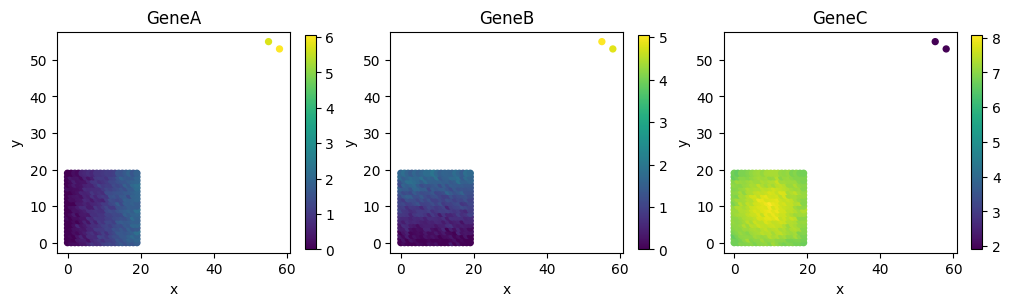

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(10, 3), constrained_layout=True)
for ax, gene in zip(axes, ['GeneA', 'GeneB', 'GeneC']):
    sc = ax.scatter(feature_df['x'], feature_df['y'], c=feature_df[gene], s=18, cmap='viridis')
    ax.set_title(gene)
    ax.set_aspect('equal')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    fig.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)
plt.show()


## ??????

?????????? convex hull???????????? SPATA2 ???? outline ? annotation ???


In [7]:
outline = ov.space.spata2_tissue_outline(adata)
outline


           x     y
vertex            
0       58.0  53.0
1       55.0  55.0
2        0.0  19.0
3        0.0   0.0
4       19.0   0.0

## ???????

???? radius-neighborhood ????????????? observation ????????????????????????


In [8]:
outliers = ov.space.spata2_identify_outliers(adata, radius=2.0, min_neighbors=2)
print(outliers.value_counts().rename(index={False: 'kept', True: 'outlier'}))
adata.obs.loc[outliers, ['region', 'total_counts']]


spata2_spatial_outlier
kept       400
outlier      2
Name: count, dtype: int64


         region  total_counts
spot_400  right     12.670201
spot_401  right     12.803800

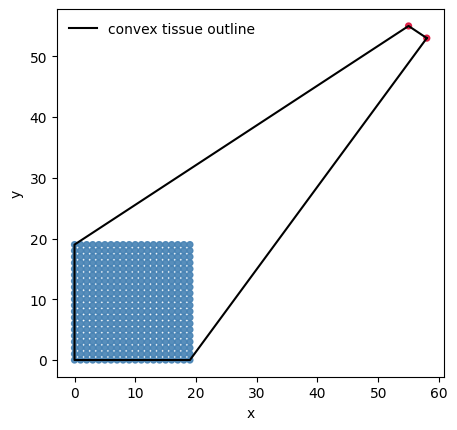

In [9]:
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(coords_df['x'], coords_df['y'], s=18, c=np.where(outliers, 'crimson', 'steelblue'), alpha=0.9)
closed = pd.concat([outline, outline.iloc[[0]]], ignore_index=True)
ax.plot(closed['x'], closed['y'], color='black', linewidth=1.5, label='convex tissue outline')
ax.set_aspect('equal')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.legend(frameon=False)
plt.show()


## ???????

`spata2_remove_outliers` ???????? copy??????????


In [10]:
filtered = ov.space.spata2_remove_outliers(adata)
print('before:', adata.n_obs, 'after:', filtered.n_obs)
filtered.obs.tail()


before: 402 after: 400


         region  total_counts  spata2_spatial_outlier
spot_395  right     10.439553                   False
spot_396  right     10.174393                   False
spot_397  right     10.298933                   False
spot_398  right     10.259729                   False
spot_399  right     10.336552                   False

## ???????????

SPATA2 R API ????????Python ????????????? scale factor????? round-trip ????


In [11]:
pixels = np.array([0, 55, 110, 220])
micrometers = ov.space.spata2_pixels_to_unit(pixels, pixels_per_unit=2.0)
roundtrip = ov.space.spata2_unit_to_pixels(micrometers, pixels_per_unit=2.0)
pd.DataFrame({'pixels': pixels, 'micrometers': micrometers, 'roundtrip_pixels': roundtrip})


   pixels  micrometers  roundtrip_pixels
0       0          0.0               0.0
1      55         27.5              55.0
2     110         55.0             110.0
3     220        110.0             220.0

## Notebook benchmark

???? benchmark ???????????? fixture ?? wall-clock ?????? `py-SPATA2` benchmark ?????????


In [12]:
import time

bench_rows = []
for label, call in [
    ('spata2_get_coords', lambda: ov.space.spata2_get_coords(adata)),
    ('spata2_join_variables', lambda: ov.space.spata2_join_variables(adata, ['region', 'GeneA', 'GeneB'])),
    ('spata2_tissue_outline', lambda: ov.space.spata2_tissue_outline(adata, write_key=None)),
    ('spata2_identify_outliers', lambda: ov.space.spata2_identify_outliers(adata, radius=2.0, min_neighbors=2, write_key=None)),
    ('spata2_remove_outliers', lambda: ov.space.spata2_remove_outliers(adata)),
]:
    start = time.perf_counter()
    result = call()
    elapsed = time.perf_counter() - start
    bench_rows.append({'operation': label, 'seconds': elapsed, 'shape': getattr(result, 'shape', (len(result),))})

pd.DataFrame(bench_rows)


                  operation   seconds     shape
0         spata2_get_coords  0.000492  (402, 3)
1     spata2_join_variables  0.000876  (402, 6)
2     spata2_tissue_outline  0.000873    (5, 2)
3  spata2_identify_outliers  0.000890    (402,)
4    spata2_remove_outliers  0.000828  (400, 3)

## ?? parity ??

?????????? SPATA2 3.1.4 `NAMESPACE`?????????? Python ????? R-style export ???? implemented?

?????

- [NAMESPACE_PARITY.md](https://github.com/omicverse/py-SPATA2/blob/master/NAMESPACE_PARITY.md)
- [spata2_namespace_parity.csv](https://github.com/omicverse/py-SPATA2/blob/master/references/spata2_namespace_parity.csv)


In [13]:
parity = pd.DataFrame(
    [
        ['R exports audited from SPATA2 3.1.4 NAMESPACE', 751],
        ['R-compatible Python symbols implemented in py-SPATA2', 16],
        ['Strict namespace coverage', '2.1%'],
        ['ov.space tutorial API functions exercised here', 8],
    ],
    columns=['metric', 'value'],
)
parity


                                              metric value
0      R exports audited from SPATA2 3.1.4 NAMESPACE   751
1  R-compatible Python symbols implemented in py-...    16
2                          Strict namespace coverage  2.1%
3     ov.space tutorial API functions exercised here     8

## ????

??????????? AnnData ?????????????????? artifact ???????? notebook ???? SPATA2 parity ????????????????????????reader/initiation?get/set/add accessors?spatial annotations?trajectories?gradient screening ? plotting?
